**Instructions:**

- Do not write your name on the assignment. Be careful about any warnings that might display some file path with your name included.
- Receiving help from classmates and/or ideas from Generative AI is allowed. **However, you must submit your own original work.**
- For questions that require coding, you need to write the relevant code and display its output. Your output should either be the direct answer to the question or clearly display the answer in it.
- For questions that require a written answer (sometimes along with the code), you need to put your answer in a Markdown cell. Writing the answer as a comment or as a print line is not acceptable.
- You need to render this file as HTML using Quarto and submit the HTML file. **Please note that this is a requirement and not optional.** A submission cannot be graded until it is properly rendered.

Proper formatting: **5 points**
- Quarto rendering **(2 points)** (If the file is rendered wrong, the correct version needs to be submitted first to be eligible for grading; 2 points will be deducted afterwards.)
- No unnecessary/redundant/commented-out code chunk, text or output. **(2 points)**
- Written answers in Markdown cells, not added as a comment or a print line. **(1 points)**

Import all the libraries and tools you need below.

In [44]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score
import matplotlib.pyplot as plt

## 1) Exploring Ridge, Lasso and ElasticNet Regression (16 points)

### a)

Define a `calc_cost_gradient_Ridge` function. It should take four inputs: (1) `model_params`, which are the (current) parameters of a Ridge Regression model ($w_0, w_1, w_2, ... , w_N$), (2) `X_train` and (3) `y_train`, which contain the training features and responses, respectively, and (4) `lambda_hp`, which is the hyperparameter of a Ridge Regression model.

The function should return two outputs: (1) `cost`, which is the Ridge cost for the given inputs, and (2) `gradient`, which is the gradient of the Ridge cost function at the input parameters.

`cost` should be a scalar value. For `gradient`, you have different options, as long as it contains all the partial derivatives: it can be a numpy vector, a list, a dictionary, etc.

**Note:** 

- This is the Ridge Regression version of the function you wrote for Exercise Set 2.
- **You are not allowed to use loops/comprehensions.** The implementation should be vectorized.
- You do not need to check or account for any invalid inputs.
- You can use the given test case to check your function.

**(8 points)**

In [45]:
def calc_cost_gradient_Ridge(model_params, X_train, y_train, lambda_hp):
    
    X = np.column_stack((np.ones(len(X_train)), X_train))
    y = np.asarray(y_train)
    
    errors = X @ model_params - y
    cost = np.mean(errors**2) + lambda_hp * np.sum(model_params**2)
    gradient = (2 / len(y)) * (X.T @ errors) + 2 * lambda_hp * model_params

    return cost, gradient

toy_model_params = np.array([0.42310646, 0.9807642, 0.68482974])
toy_X_train = pd.DataFrame([[1,2],[3,4],[5,6]])
toy_y_train = pd.Series([20,30,40])
calc_cost_gradient_Ridge(toy_model_params, toy_X_train, toy_y_train,0.1)

# Should return
    # cost: 600.7941952248136
    # gradient: w0: -47.705942668000006; w1,w2: -160.95903803, -208.80878888

(600.7941952248136, array([ -47.70594267, -160.95903803, -208.80878888]))

### b)

Why would it be problematic to write the Lasso Regression version of the `calc_cost_gradient` function? 

Your explanation should include the tools that are included in the Gradient Descent algorithm and a specific aspect of Lasso Regression. In other words, there is a very specific and math-related answer for this question; any generic answer will not be accepted.

**(4 points)**

Gradient Descent requires to calculate the gradient of the cost function to update the model parameters. Because Lasso uses an L1 penalty, which includes the absolute value of the coefficients, the derivative of the absolute value function is undefined at zero. For this reason, implementing a Lasso Regression is problematic using standard Gradient Descent, since the gradient cannot be calculated w=0. Different from Ridge Regression, whose squared penalty can always be differentiable, Lasso requires a different approach.

### c)

For a given dataset, it is not possible to know whether Lasso or Ridge Regression would work better before actually applying both models. However, if ElasticNet Regression is used, it is guaranteed to work **at least as well as** both Ridge and Lasso Regression. Explain why this is the case.

Assume that you have the computational resources to explore a vast set of hyperparameters and you are able to tune the hyperparameters to their best values for all the models in this question.

Your reasoning should include the cost functions of Lasso, Ridge and ElasticNet Regression.

**(4 points)**

ElasticNet is a combination of both Lasso and Ridge Regression. It's cost function combines both L1 and L2 regularization:

- **Ridge:** $J = MSE + \lambda \sum w_j^2$
- **Lasso:** $J = MSE + \lambda \sum |w_j|$
- **ElasticNet:** $J = MSE + \lambda[\alpha \sum |w_j| + (1-\alpha)\sum w_j^2]$

When $\alpha = 0$, ElasticNet becomes Ridge and when $\alpha = 1$, it becomes Lasso. Assuming we have unlimited computational power, ElasticNet can optimally tune all hyperparameters, which means ElasticNet can choose either of these models or a combination of them, meaning that its best achievable performance cannot be worse than the best achievable performance of Ridge or Lasso on the same evaluation.


---

*AI Usage Note: Used ChatGPT-6.1 Sol to format the Ridge, Lasso, and ElasticNet cost functions in Markdown format.*

*Prompt: "Give me the Ridge, Lasso, and ElasticNet Regression cost functions in a nice Markdown format."*

*LLM's Output:*
- **Ridge:** $J = MSE + \lambda \sum w_j^2$
- **Lasso:** $J = MSE + \lambda \sum |w_j|$
- **ElasticNet:** $J = MSE + \lambda[\alpha \sum |w_j| + (1-\alpha)\sum w_j^2]$

## 2) Deriving the Gradients of the Binary Cross-Entropy Cost (20 points)

Remember that the cost function for Logistic Regression is binary cross-entropy (BCE) and its formula is as follows:

$$ BCE = \displaystyle-\frac{1}{M}\sum_{i=1} ^{M} y^{(i)}log(\sigma(\mathbf{w}^T\mathbf{x}^{(i)})) + (1 - y^{(i)})log(1 - \sigma(\mathbf{w}^T\mathbf{x}^{(i)}))$$

Using the formula given above and the tips given in the lectures, derive the gradient vector of the BCE function with respect to the model parameters ($w_0, w_1, w_2, ... , w_N$). You can keep the partial derivative with respect to $w_0$ separate, if you wish. (You do not have to.)

**Note:**

- Your gradient formula(s) should be directly implementable for full credit, i.e. **it should not contain a sigma sum except for the partial derivative of $w_0$.**
- You can submit your derivations in any format as long as they are legible. You can include an additional file to the submission if necessary.

![BCE Gradient Derivation](derivation.png)

$$
BCE = -\frac{1}{M}\sum_{i=1}^{M}
\left[
y^{(i)}\log(\sigma(\mathbf{w}^T\mathbf{x}^{(i)}))
+
(1-y^{(i)})\log(1-\sigma(\mathbf{w}^T\mathbf{x}^{(i)}))
\right]
$$

$$
J(\mathbf{w}) = -\frac{1}{M}\sum_{i=1}^{M}
\left[
y^{(i)}\log(\hat{y}^{(i)})
+
(1-y^{(i)})\log(1-\hat{y}^{(i)})
\right]
$$

$$
\hat{y}^{(i)} = \sigma(z^{(i)}),
\qquad
z^{(i)} = \mathbf{w}^T\mathbf{x}^{(i)}
$$

$$
\hat{y}^{(i)} = \sigma(\mathbf{w}^T\mathbf{x}^{(i)})
$$

$$
\frac{\partial J}{\partial w_j}
=
-\frac{1}{M}\sum_{i=1}^{M}
\left[
\frac{y^{(i)}}{\hat{y}^{(i)}}
-
\frac{1-y^{(i)}}{1-\hat{y}^{(i)}}
\right]
\frac{\partial \hat{y}^{(i)}}{\partial w_j}
$$

$$
\sigma'(z)
=
\frac{e^{-z}}{(1+e^{-z})^2}
=
\sigma(z)(1-\sigma(z))
$$

$$
\frac{\partial \hat{y}^{(i)}}{\partial w_j}
=
\hat{y}^{(i)}(1-\hat{y}^{(i)})x_j^{(i)}
$$

$$
\frac{\partial J}{\partial w_j}
=
-\frac{1}{M}\sum_{i=1}^{M}
\left[
\frac{y^{(i)}}{\hat{y}^{(i)}}
-
\frac{1-y^{(i)}}{1-\hat{y}^{(i)}}
\right]
\hat{y}^{(i)}(1-\hat{y}^{(i)})x_j^{(i)}
$$

$$
\frac{\partial J}{\partial w_j}
=
-\frac{1}{M}\sum_{i=1}^{M}
\left[
y^{(i)}(1-\hat{y}^{(i)})
-
(1-y^{(i)})\hat{y}^{(i)}
\right]x_j^{(i)}
$$

$$
\frac{\partial J}{\partial w_j}
=
-\frac{1}{M}\sum_{i=1}^{M}
\left[
y^{(i)}
-
y^{(i)}\hat{y}^{(i)}
-
\hat{y}^{(i)}
+
y^{(i)}\hat{y}^{(i)}
\right]x_j^{(i)}
$$

$$
\frac{\partial J}{\partial w_j}
=
-\frac{1}{M}\sum_{i=1}^{M}
\left[
y^{(i)}-\hat{y}^{(i)}
\right]x_j^{(i)}
$$

$$
\boxed{
\frac{\partial J}{\partial w_j}
=
\frac{1}{M}\sum_{i=1}^{M}
(\hat{y}^{(i)}-y^{(i)})x_j^{(i)}
}
$$

$$
X_b =
\begin{bmatrix}
1 & x_1^{(1)} & \cdots & x_N^{(1)} \\
1 & x_1^{(2)} & \cdots & x_N^{(2)} \\
\vdots & \vdots & \ddots & \vdots \\
1 & x_1^{(M)} & \cdots & x_N^{(M)}
\end{bmatrix}
$$

$$
\hat{\mathbf{y}} = \sigma(X_b\mathbf{w})
$$

$$
\boxed{
\nabla_{\mathbf{w}}J
=
\frac{1}{M}X_b^T
\left(
\sigma(X_b\mathbf{w})-\mathbf{y}
\right)
}
$$


---

*AI Usage Note: Used ChatGPT-6.1 Sol to transform the derivation into Markdown format by sending the picture to the generative LLM.*


## 3) Logistic Regression with scikit-learn (11 points)

### a)

Read the **heart_disease_classification.csv** file. Each observation is a patient. The `target` variable represents if the patient is at risk of heart disease (1) or not (0). All the other variables are medical measurements and will be used as features. 

Split the features and the response into different variables. 

**(1 point)**

In [46]:
df = pd.read_csv('heart_disease_classification.csv')

X = df.drop(columns=['target'])
y = df["target"]

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### b)

One-hot-encode the `cp` and `thal` features, i.e. create dummy variables out of them. If you are not familiar with the pandas library, you may need to look up a function that implements this very quickly.

The rest of the features should stay the same. 

**Note:** `drop_first` input is up to you; it should work either way.

**(2 points)**

In [47]:
X = pd.get_dummies(X, columns=['cp', 'thal'], dtype=int)

X

,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,cp_0,cp_1,cp_2,cp_3,thal_0,thal_1,thal_2,thal_3
0,63,1,145,233,1,0,150,0,2.3,0,0,0,0,0,1,0,1,0,0
1,37,1,130,250,0,1,187,0,3.5,0,0,0,0,1,0,0,0,1,0
2,41,0,130,204,0,0,172,0,1.4,2,0,0,1,0,0,0,0,1,0
3,56,1,120,236,0,1,178,0,0.8,2,0,0,1,0,0,0,0,1,0
4,57,0,120,354,0,1,163,1,0.6,2,0,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,140,241,0,1,123,1,0.2,1,0,1,0,0,0,0,0,0,1
299,45,1,110,264,0,1,132,0,1.2,1,0,0,0,0,1,0,0,0,1
300,68,1,144,193,1,1,141,0,3.4,1,2,1,0,0,0,0,0,0,1
301,57,1,130,131,0,1,115,1,1.2,1,1,1,0,0,0,0,0,0,1


### c)

Split the data into training and test sets with a 80%-20% ratio. Use `random_state=42` for reproducible results. Do **not** stratify. **(1 points)**

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### d)

Scale the training and test data. **(1 point)**

In [49]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### e)

Why do we scale the datasets before using the Logistic Regression model? **(1.5 points)** Assuming the features are in different orders of magnitude in a given dataset, can we train the Logistic Regression model in such a way that scaling would not be necessary? (Such as the Least Squares solution of a Linear Regression model) **(1 point)** Why or why not? **(1.5 points)**

Logistic Regression is trained with numerical optimization. When some features have much larger values than others, optimization could converge slower or evem become numerically unstable. Scaling gets the features on comparable scales, which makes the training more efficient.

No because there is no closed form solution, so we have to use an iterative method like gradient descent, and gradient descent is also sensitive to feature scale, so scaling is needed.

### f)

Using the scikit-learn library, create and train a Logistic Regression model. The model should **not** have any Lasso or Ridge penalty. Evaluate the model using test accuracy and recall. You can keep the probability threshold at 0.5, which is the default value. **(2 points)**

You will need to match (or exceed) these output scores with the model you will implement in the next question.

In [50]:
model = LogisticRegression(penalty=None, max_iter=10000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Test Accuracy:", accuracy)
print("Test Recall:", recall)

Test Accuracy: 0.8852459016393442
Test Recall: 0.875


## 4) Implementing Logistic Regression with Gradient Descent (44 points)

### a)

Define two short functions:

- `initialize`: This function can be the same as the one written for Exercise Set 1. **(1 point)**
- `sigmoid`: This function should take one input and return its sigmoid value. The equation for the sigmoid function is given in the lecture. You do not need to check or account for any invalid inputs. **(3 points)**

In [51]:
def initialize(dim):
    return np.random.rand(dim + 1)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

print(sigmoid(0)) # should return 0.5
print(sigmoid(2.3)) # should return 0.9088770389851438
print(sigmoid(-1.5)) # should return 0.18242552380635635

0.5
0.9088770389851438
0.18242552380635635


### b)

Define a function called `predict`. It should take three inputs: `model_params`, which are the parameters of a Logistic Regression model ($w_0, w_1, w_2, ... , w_N$), `X_test`, which contains the features of the test data and `threshold`, which is the probability threshold imposed on the model output to obtain the class predictions.

The function should return the predicted **classes** of the Logistic Regression model. You do not need to check or account for any invalid inputs. **You are not allowed to use loops/comprehensions.**

**(5 points)**

In [52]:
def predict(model_params, X_test, threshold):
    X = np.column_stack((np.ones(len(X_test)), X_test))
    probabilities = sigmoid(X @ model_params)
    return (probabilities >= threshold).astype(int)

input_params = np.array([0.42310646, 0.9807642, 0.68482974])
toy_data = pd.DataFrame([[1,-2],[3,-4],[5,-6]])
print(predict(input_params, toy_data, 0.7)) # Should return [0, 0, 1]
print(predict(input_params, toy_data, 0.6)) # Should return [0, 1, 1]

[0 0 1]
[0 1 1]


### c)

Define a function called `calc_cost_gradient`. Its inputs and outputs should be the same as the function written for Exercise Set 2. However, the function will be used for Logistic Regression in this assignment, so the cost and the gradient should be implemented according to the cost function given and the formulas you derived in Question 2. **You are not allowed to use loops/comprehensions.**

**(15 points)**

In [53]:
def calc_cost_gradient(model_params, X_train, y_train):
    X = np.column_stack((np.ones(len(X_train)), X_train))
    y_pred = sigmoid(X @ model_params)

    cost = -np.mean(y_train * np.log(y_pred) + (1 - y_train) * np.log(1 - y_pred))
    gradient = (X.T @ (y_pred - y_train)) / len(y_train)

    return cost, gradient


toy_model_params = np.array([0.42310646, 0.9807642, 0.68482974])
toy_X_train = pd.DataFrame([[1,2],[3,4],[5,6]])
toy_y_train = pd.Series([20,30,40])
calc_cost_gradient(toy_model_params, toy_X_train, toy_y_train)

# Should return
    # cost: -199.22378214834978
    # gradient: w0: -29.020359523261124; w1,w2: -100.35528415, -129.37564367

(-199.22378214834978, array([ -29.02035952, -100.35528415, -129.37564367]))

### d)

Define a function called `GradientDescent`. This function will implement the Gradient Descent algorithm for Logistic Regression. 

It should be mostly similar to the function written for Exercise Set 3, with one important difference:

- There should be one more input, called `tol`. At every iteration, the previous and the current **w** (parameter) vectors should be compared. If the [second norm](https://mathworld.wolfram.com/L2-Norm.html) of their difference vector is below the `tol` value, the algorithm should stop.
- If the maximum number of iterations is reached and the difference is still above the tolerance, the function should print: **Warning: Algorithm may not have converged.**

Please note that the function still should: 

- Print the minimized Binary Cross-Entropy (BCE) cost.
- Display a line plot that shows how the cost changes through the iterations.
- Return one output, `model_params`, which contains the optimal model parameters.

**(10 points)**

In [54]:
def GradientDescent(model_params, X_train, y_train, lr, iters, tol):
    costs = []

    for i in range(iters):
        cost, gradient = calc_cost_gradient(model_params, X_train, y_train)
        costs.append(cost)

        new_params = model_params - lr * gradient

        if np.linalg.norm(new_params - model_params, 2) < tol:
            model_params = new_params
            break

        model_params = new_params

    else:
        print("Warning: Algorithm may not have converged.")

    final_cost, _ = calc_cost_gradient(model_params, X_train, y_train)

    print("Final BCE:", final_cost)

    plt.plot(costs)
    plt.show()

    return model_params


### e)

Define a function called `logistic_regression`. This is your actual custom model. The function body should include most of the functions you defined above.

The function should: 

- Take eight inputs: `X_train`, `y_train`, `X_test`, `y_test`, `lr`, `iters`, `tol`, and `threshold` all of which should be self-explanatory at this point. (`threshold` should have a default value of 0.5.)
- Initialize the model parameters.
- Run the Gradient Descent algorithm to find the optimal parameters.
- Print the final (minimized) BCE cost and visualize how it changes through the iterations.
- Predict the test classes.
- Evaluate and print the test accuracy and recall.
- Return the optimal parameters.

**The entire function (including the definition and the return lines) should be written in 7 lines of code at most for credit.**

**(3 points)**

In [55]:
def logistic_regression(X_train, y_train, X_test, y_test, lr, iters, tol, threshold = 0.5):
    model_params = initialize(X_train.shape[1])
    model_params = GradientDescent(model_params, X_train, y_train, lr, iters, tol)
    y_pred = predict(model_params, X_test, threshold)
    print("Test Accuracy:", accuracy_score(y_test, y_pred))
    print("Test Recall:", recall_score(y_test, y_pred))
    return model_params

### f)

Call the `logistic_regression` function with the data preprocessed in Question 3. Experiment with the learning rate, the number of iterations and the tolerance to find reasonable values. 

**Note:**
- **Use the threshold with its default value.** This is necessary for a fair comparison with the results in Question 3.
- You need to match (or exceed) the test accuracy and recall found in Question 3.
- You should **not** see a warning message, i.e. the algorithm should converge and stop properly.

**(7 points)**

Final BCE: 0.34433065795555556


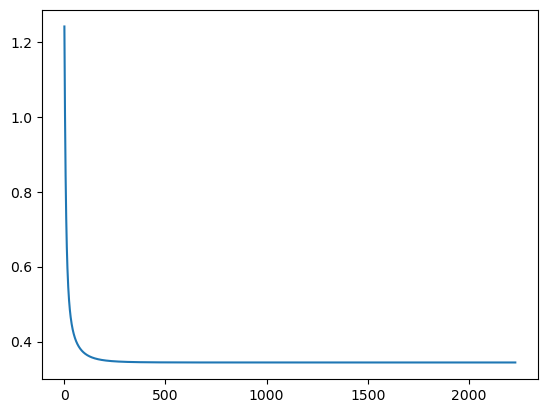

Test Accuracy: 0.8852459016393442
Test Recall: 0.875


In [56]:
np.random.seed(1) # Random seed for reproducible initialization

model_params = logistic_regression(
    X_train_scaled, y_train,
    X_test_scaled, y_test,
    lr=0.1,
    iters=10000,
    tol=1e-6
)


## 5) Final Question (4 points)

If there are off-the-shelf Machine Learning models available in scikit-learn or some other library, what is the point of implementing any model from scratch? Give two reasons.

**Note:** This is an open-ended question. You may write your own ideas or do some research for any possible reasons. In the latter case, **cite your sources**.

1) I believe that implementing a model from scratch is very helpful to understand how does the model actually work. Using the scikit-learn library makes it really easy to implement a model, but understandying what the model is actually doing, how is it doing it, how does it trains data and hot it predicts is really important to understand the model better and know how to use it and when to use it.

2) Implementing our own model is also helpful because we can optimize it and tune in a way that gives us more control and flexibility over the training compared to the already available libraries. In the model we built, we created a stopping condition for Gradient Descent, giving us more control on when the model needs to stop training.